In [2]:
import keystroke_cvae_freetext_module as kc

In [3]:
kc.set_seed(42)

In [4]:
df, X, C, scaler, encoder, feature_cols, meta_cols, clip_bounds = kc.load_data("free-text.csv")

Rows before cleaning: 562583
Rows after cleaning : 562372
Dropped rows        : 211
Cleaned data shape: (562372, 9)
Feature shape     : (562372, 5)
Condition shape   : (562372, 101)


In [5]:
df_train, df_val, df_test, X_train, X_val, X_test, C_train, C_val, C_test = kc.split_data_by_participant_session(df, X, C)

Train: (393656, 5) (393656, 101)
Val  : (84362, 5) (84362, 101)
Test : (84354, 5) (84354, 101)


In [6]:
train_loader, val_loader = kc.create_loaders(X_train, X_val, C_train, C_val, batch_size=256)

In [7]:
model = kc.build_model(X_train.shape[1], C_train.shape[1], latent_dim=16, dropout=0.05)

In [8]:
model, train_losses, val_losses = kc.train(
    model,
    train_loader,
    val_loader,
    epochs=60,
    lr=0.0003,
    beta=0.00005,
    patience=10
)

Epoch 1/60 | Train 0.030749 | Val 0.003344
Epoch 2/60 | Train 0.003616 | Val 0.002391
Epoch 3/60 | Train 0.002845 | Val 0.001442
Epoch 4/60 | Train 0.002192 | Val 0.001260
Epoch 5/60 | Train 0.001815 | Val 0.000853
Epoch 6/60 | Train 0.001559 | Val 0.000952
Epoch 7/60 | Train 0.001527 | Val 0.000655
Epoch 8/60 | Train 0.001424 | Val 0.000849
Epoch 9/60 | Train 0.001279 | Val 0.000705
Epoch 10/60 | Train 0.001212 | Val 0.000552
Epoch 11/60 | Train 0.001218 | Val 0.000933
Epoch 12/60 | Train 0.001206 | Val 0.000635
Epoch 13/60 | Train 0.001081 | Val 0.001527
Epoch 14/60 | Train 0.001129 | Val 0.000496
Epoch 15/60 | Train 0.001006 | Val 0.000497
Epoch 16/60 | Train 0.001016 | Val 0.000993
Epoch 17/60 | Train 0.000951 | Val 0.000486
Epoch 18/60 | Train 0.000865 | Val 0.000535
Epoch 19/60 | Train 0.000881 | Val 0.000611
Epoch 20/60 | Train 0.000858 | Val 0.000372
Epoch 21/60 | Train 0.000828 | Val 0.000417
Epoch 22/60 | Train 0.000782 | Val 0.000397
Epoch 23/60 | Train 0.000809 | Val 0.0004

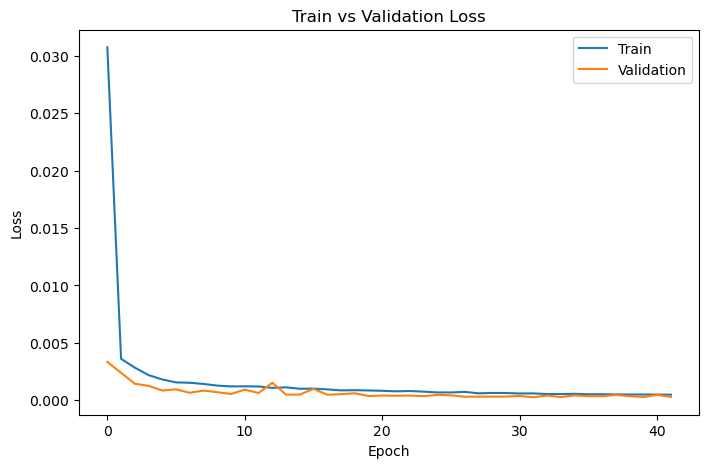

In [9]:
kc.plot_loss(train_losses, val_losses)

In [10]:
synthetic_df = kc.generate_same_shape(
    model,
    df,
    scaler,
    encoder,
    feature_cols,
    meta_cols,
    clip_bounds,
    temperature=1.15,
    moment_match=True
)

Real shape      : (562372, 9)
Synthetic shape : (562372, 9)


In [11]:
kc.save_dataset(synthetic_df, "synthetic_free_text.csv")

Saved dataset to: /Users/shikharraj/Desktop/BB final project/FREE_TEXT/VAE Generator/synthetic_free_text.csv


In [12]:
kc.compare_stats(df, synthetic_df, feature_cols)

REAL MEANS
DU.key1.key1    0.159343
DD.key1.key2    0.271341
DU.key1.key2    0.430275
UD.key1.key2    0.094820
UU.key1.key2    0.254368
dtype: float64

SYNTHETIC MEANS
DU.key1.key1    0.428897
DD.key1.key2    0.271341
DU.key1.key2    0.711197
UD.key1.key2    0.094820
UU.key1.key2    0.275339
dtype: float64

REAL STDS
DU.key1.key1    1.047118
DD.key1.key2    1.662964
DU.key1.key2    1.365906
UD.key1.key2    1.075000
UU.key1.key2    0.299841
dtype: float64

SYNTHETIC STDS
DU.key1.key1    0.900651
DD.key1.key2    1.662962
DU.key1.key2    1.164495
UD.key1.key2    1.074990
UU.key1.key2    0.275595
dtype: float64


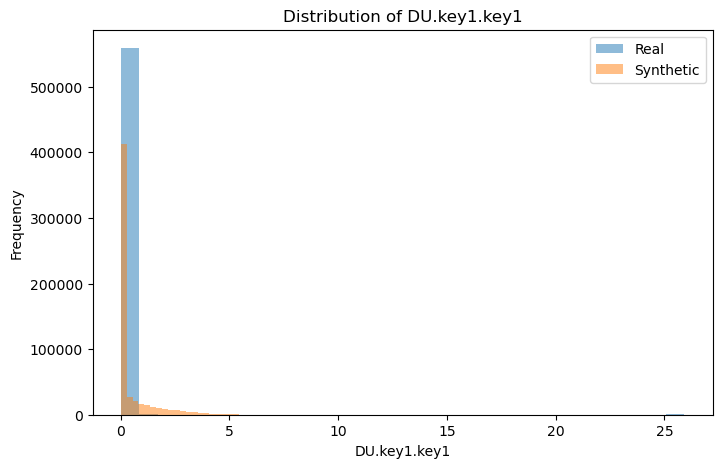

In [13]:
kc.plot_feature_hist(df, synthetic_df, feature_cols[0])